In [ ]:
!pip install geopandas
!pip install contextily
!pip install cartopy
!pip install networkx[default]
!pip install pygplates

In [ ]:
import gzip
import shutil
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from cartopy import *
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
from shapely import *
import json
import pandas as pd
import numpy as np
import networkx as nx
from collections import *
import pygplates
from shapely.ops import split, unary_union
from shapely.geometry import LineString

In [ ]:
rotationDf = pd.read_csv('rotation.rot',
                 delim_whitespace=True,
                 names=['moving_plate_id',
                       'age_ma',
                       'euler_pole_lat',
                       'euler_pole_lon',
                       'rotation_angle',
                       'fixed_plate_id'],
                 comment='!')
rotationDf

<ipython-input-43-11bbe0f7a0e9>:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  rotationDf = pd.read_csv('rotation.rot',


,moving_plate_id,age_ma,euler_pole_lat,euler_pole_lon,rotation_angle,fixed_plate_id
0,101,940.0,45.5566,176.2356,-196.8912,0
1,101,1050.0,49.1843,178.3948,-182.5947,0
2,999,1066.0,49.7419,179.5839,-146.5091,0
3,101,1070.0,48.2588,179.8680,-174.4098,0
4,999,1076.0,46.7483,-167.5888,-154.1052,0
...,...,...,...,...,...,...
383,811001,1751.0,65.4307,136.0295,-35.0472,801
384,501001,0.0,90.0000,0.0000,0.0000,101
385,501001,1699.1,90.0000,0.0000,0.0000,101
386,501001,1760.0,-62.7319,85.1837,44.2470,101


In [ ]:
polygonDf = pd.read_pickle('coastlinesDF.pkl')
polygonDf

,featureType,polygons,plateId,name,begin,end
0,Basin,"[[[19.85355599999994, -155.08441699999997], [1...",901,Pacific,0.4,0.0
1,Basin,"[[[21.033472000000103, -156.59055600000002], [...",901,Pacific,1.3,0.0
2,Basin,"[[[21.461527999999987, -157.723194], [21.31055...",901,Pacific,2.6,0.0
3,Basin,"[[[21.960443999999995, -159.332444], [21.86891...",901,Pacific,5.1,0.0
4,Basin,"[[[21.161944000000034, -156.710194], [21.05002...",901,Pacific,1.3,0.0
...,...,...,...,...,...,...
2072,ClosedContinentalBoundary,"[[[-76.29476333521959, -146.72900324038454], [...",804,Marie Byrd Land,600.0,0.0
2073,ClosedContinentalBoundary,"[[[-37.862010722364616, 176.81236263750355], [...",8065,North Island New Zealand,280.0,0.0
2074,ClosedContinentalBoundary,"[[[-37.862010722364616, 176.81236263750355], [...",8064,North Island New Zealand,280.0,0.0
2075,ClosedContinentalBoundary,"[[[-41.7516182005166, 173.10610375500642], [-4...",80613,North Island New Zealand,280.0,0.0


In [ ]:
def create_plate_map(polygons, title='Tectonic Plates Reconstruction'):
    fig = plt.figure(figsize=(15, 10))
    proj = ccrs.Robinson()
    ax = plt.axes(projection=proj)

    # Combine all polygons into a single feature
    combined_feature = cfeature.ShapelyFeature(
        polygons,
        crs=ccrs.PlateCarree(),
        facecolor='wheat',
        edgecolor='black'
    )

    ax.add_feature(combined_feature)
    ax.gridlines()
    plt.title(title)

    return fig, ax

In [ ]:
dg = nx.DiGraph()
for (movingPlateId,fixedPlateId), (minAge,maxAge) in rotationDf.groupby(['moving_plate_id', 'fixed_plate_id'])['age_ma'].agg(['min', 'max']).iterrows():
    dg.add_edge(movingPlateId, fixedPlateId, minAge=minAge, maxAge=maxAge)

In [ ]:
def latlon_to_xyz(points):
    """
    Convert latitude/longitude coordinates to 3D Cartesian coordinates on a unit sphere.

    Parameters:
    points (np.array): Nx2 array of [latitude, longitude] pairs in degrees

    Returns:
    np.array: Nx3 array of [x, y, z] coordinates
    """
    # Convert degrees to radians
    lat_rad = np.radians(points[:, 0])
    lon_rad = np.radians(points[:, 1])

    # Convert to 3D coordinates
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)

    # Stack coordinates into Nx3 array
    xyz = np.column_stack((x, y, z))
    return xyz

def xyz_to_latlon(points):
    """
    Convert 3D Cartesian coordinates back to latitude/longitude.

    Parameters:
    points (np.array): Nx3 array of [x, y, z] coordinates

    Returns:
    np.array: Nx2 array of [latitude, longitude] pairs in degrees
    """
    # Normalize the vectors
    norm = np.sqrt(np.sum(points**2, axis=1))
    points = points / norm[:, np.newaxis]

    # Convert to lat/lon
    lat = np.degrees(np.arcsin(points[:, 2]))
    lon = np.degrees(np.arctan2(points[:, 1], points[:, 0]))

    # Wrap around globe for long
    lon = np.where(lon < -180, lon + 360, lon)
    lon = np.where(lon > 180, lon - 360, lon)

    return np.column_stack((lat, lon))

In [ ]:
import numpy as np
from scipy.linalg import logm, expm

def slerp_rotation_matrices(R1, R2, t):
    """
    SLERP interpolation between two rotation matrices.
    Args:
        R1, R2: 3x3 rotation matrices
        t: Interpolation parameter (0 to 1)
    Returns:
        Interpolated rotation matrix
    """
    if t == 0: return R1
    if t == 1: return R2

    # Compute relative rotation
    R = R1.T @ R2

    # Convert to axis-angle representation
    cos_theta = np.clip((np.trace(R) - 1) / 2, -1, 1)
    theta = np.arccos(cos_theta)
    if abs(theta) < 1e-10:
        return R1

    log_R = theta * (R - R.T) / (2 * np.sin(theta))

    # Interpolate
    return R1 @ expm(t * log_R)

In [ ]:
def create_rotation_matrix(k, theta):
    """
    Create a 3D rotation matrix for rotation around axis k by angle theta.

    Parameters:
    k (np.array): Axis of rotation (will be normalized)
    theta (float): Rotation angle in radians

    Returns:
    np.array: 3x3 rotation matrix
    """
    # Normalize the rotation axis
    k = k / np.linalg.norm(k)
    kx, ky, kz = k

    # Compute cos and sin of theta
    c = np.cos(theta)
    s = np.sin(theta)
    C = 1 - c

    # Create the rotation matrix
    R = np.array([
        [kx*kx*C + c,    kx*ky*C - kz*s,  kx*kz*C + ky*s],
        [ky*kx*C + kz*s,  ky*ky*C + c,    ky*kz*C - kx*s],
        [kz*kx*C - ky*s,  kz*ky*C + kx*s,  kz*kz*C + c]
    ])

    return R

def rotate_points(points, k, theta):
    """
    Rotate multiple points around axis k by angle theta.

    Parameters:
    points (np.array): Nx3 array of points to rotate
    k (np.array): Axis of rotation
    theta (float): Rotation angle in radians

    Returns:
    np.array: Nx3 array of rotated points
    """
    R = create_rotation_matrix(k, theta)
    # Use matrix multiplication to rotate all points at once
    rotated_points = np.dot(points, R.T)  # right to left multiplication
    return rotated_points

In [ ]:
def plotRotatedPolygon(plateId, fixedPlateId, originalPolygon, reconstructionYear):
    # find path of rotations with graph
    # interpolate if needed
    # multiply adjacent rotation matrices
    # convert points to xyz
    # multiply by product of rotation matrices
    # back to lat lon
    row_match = rotationDf[
        (rotationDf['moving_plate_id'] == plateId) &
        (rotationDf['fixed_plate_id'] == fixedPlateId) &
        (rotationDf['age_ma'] == reconstructionYear)
    ]

    if not row_match.empty:
        row = row_match.iloc[0]

        # Cache the rotation axis conversion
        pole_xyz = latlon_to_xyz(
            np.array([[row['euler_pole_lat'], row['euler_pole_lon']]])
        )[0]

        theta = np.radians(row['rotation_angle'])

        rotatedPoints = xyz_to_latlon(
            rotate_points(
                latlon_to_xyz(originalPolygon),
                pole_xyz,
                theta
            )
        )


    # else:
    #     # print('empty')
    #     # print(rotationDf[(rotationDf['moving_plate_id'] == plateId)].sort_values(by='age_ma', ascending=True))
    #     lowerRow = rotationDf[(rotationDf['moving_plate_id'] == plateId) & (rotationDf['fixed_plate_id'] == fixedPlateId) & (rotationDf['age_ma'] < reconstructionYear)].sort_values(by='age_ma', ascending=True)
    #     upperRow = rotationDf[(rotationDf['moving_plate_id'] == plateId) & (rotationDf['fixed_plate_id'] == fixedPlateId) & (rotationDf['age_ma'] > reconstructionYear)].sort_values(by='age_ma', ascending=True)
    #     if lowerRow.empty or upperRow.empty:
    #         print(f'{plateId}->{fixedPlateId}')
    #         print('something was empty!')
    #         return originalPolygon

    #     lowerRow = lowerRow.iloc[-1]
    #     upperRow = upperRow.iloc[0]

    #     interpolatedRotationMatrix = slerp_rotation_matrices(
    #         create_rotation_matrix(
    #             latlon_to_xyz(np.array(lowerRow[['euler_pole_lat', 'euler_pole_lon']]).reshape(1,2))[0],
    #             np.radians(lowerRow['rotation_angle'])
    #         ),
    #         create_rotation_matrix(
    #             latlon_to_xyz(np.array(upperRow[['euler_pole_lat', 'euler_pole_lon']]).reshape(1,2))[0],
    #             np.radians(upperRow['rotation_angle'])
    #         ),
    #         (reconstructionYear - lowerRow['age_ma']) / (upperRow['age_ma'] - lowerRow['age_ma'])
    #     )
    #     rotatedPoints = xyz_to_latlon(
    #         np.dot(latlon_to_xyz(originalPolygon), interpolatedRotationMatrix.T)
    #     )
    else:
        key = (plateId, fixedPlateId, reconstructionYear)
        if key in interpolated_rotation_cache:
            interpolatedRotationMatrix = interpolated_rotation_cache[key]
        else:
            lowerRow = rotationDf[(rotationDf['moving_plate_id'] == plateId) &
                                (rotationDf['fixed_plate_id'] == fixedPlateId) &
                                (rotationDf['age_ma'] < reconstructionYear)].sort_values(by='age_ma', ascending=True)
            upperRow = rotationDf[(rotationDf['moving_plate_id'] == plateId) &
                                (rotationDf['fixed_plate_id'] == fixedPlateId) &
                                (rotationDf['age_ma'] > reconstructionYear)].sort_values(by='age_ma', ascending=True)

            if lowerRow.empty or upperRow.empty:
                print(f'{plateId}->{fixedPlateId}')
                print('something was empty!')
                return originalPolygon

            lowerRow = lowerRow.iloc[-1]
            upperRow = upperRow.iloc[0]

            interpolatedRotationMatrix = slerp_rotation_matrices(
                create_rotation_matrix(
                    latlon_to_xyz(np.array(lowerRow[['euler_pole_lat', 'euler_pole_lon']]).reshape(1,2))[0],
                    np.radians(lowerRow['rotation_angle'])
                ),
                create_rotation_matrix(
                    latlon_to_xyz(np.array(upperRow[['euler_pole_lat', 'euler_pole_lon']]).reshape(1,2))[0],
                    np.radians(upperRow['rotation_angle'])
                ),
                (reconstructionYear - lowerRow['age_ma']) / (upperRow['age_ma'] - lowerRow['age_ma'])
            )

            interpolated_rotation_cache[key] = interpolatedRotationMatrix

        rotatedPoints = xyz_to_latlon(
            np.dot(latlon_to_xyz(originalPolygon), interpolatedRotationMatrix.T)
        )



    # create_plate_map([Polygon(rotatedPoints)], f'{reconstructionYear} Rotation')
    return rotatedPoints

interpolated_rotation_cache = {}

In [ ]:
def filterEdgeForAge(age):
    def filter_edge(n1, n2):
        return dg[n1][n2].get("minAge") < age < dg[n1][n2].get("maxAge")

    return filter_edge

def rotatePolygonWithRelativePlates(plateId, originalPolygon, reconstructionYear):
    # this subgraph should be input to func since multiple calls to same reconstructionYear for multiple plates
    subgraph = nx.subgraph_view(dg, filter_edge=filterEdgeForAge(reconstructionYear))
    try:
        path = nx.shortest_path(subgraph, source=plateId, target=0)
        rotatedPolygon = originalPolygon
        for i in range(0, len(path)-1):
            rotatedPolygon = plotRotatedPolygon(path[i], path[i+1], rotatedPolygon, reconstructionYear)
    except:
        return originalPolygon

    return rotatedPolygon

In [ ]:
def getReconstructedPolygons(reconstructionTime):
    rotatedPolygons = []
    # reconstructionTime = 100
    for row,plate in polygonDf[polygonDf['begin'] > reconstructionTime].iterrows():
        for polygon in plate['polygons']:
            rotated = rotatePolygonWithRelativePlates(plate['plateId'], np.array(polygon), reconstructionTime)
            lonLat = [[i[1],i[0]] for i in rotated]
            rotatedPolygons.append(lonLat)

    return rotatedPolygons

In [ ]:
from shapely.geometry import Polygon, MultiPolygon

def remap_to_continuous_range(geom):
    """
    After splitting, shift longitudes so each geometry stays on one side of the globe.
    Supports both Polygon and MultiPolygon.
    """
    def shift_coords(coords):
        lons = np.array([pt[0] for pt in coords])
        if max(lons) - min(lons) > 180:
            return [((lon + 360) if lon < 0 else lon, lat) for lon, lat in coords]
        else:
            return coords

    if isinstance(geom, Polygon):
        new_coords = shift_coords(geom.exterior.coords)
        return Polygon(new_coords)

    elif isinstance(geom, MultiPolygon):
        new_polys = []
        for poly in geom.geoms:
            new_coords = shift_coords(poly.exterior.coords)
            new_polys.append(Polygon(new_coords))
        return MultiPolygon(new_polys)

    else:
        # Unexpected geometry type
        return geom


def fixAntimeridianCrossingPolygon(polygons):
    antimeridian = LineString([(180, -90), (180, 90)])
    all_split_polys = []

    for poly_coords in polygons:
        poly = Polygon(poly_coords)
        if not poly.is_valid:
            poly = poly.buffer(0)

        if poly.intersects(antimeridian):
            result = split(poly, antimeridian)
            for geom in result.geoms:
                all_split_polys.append(remap_to_continuous_range(geom))
        else:
            all_split_polys.append(remap_to_continuous_range(poly))


    return all_split_polys


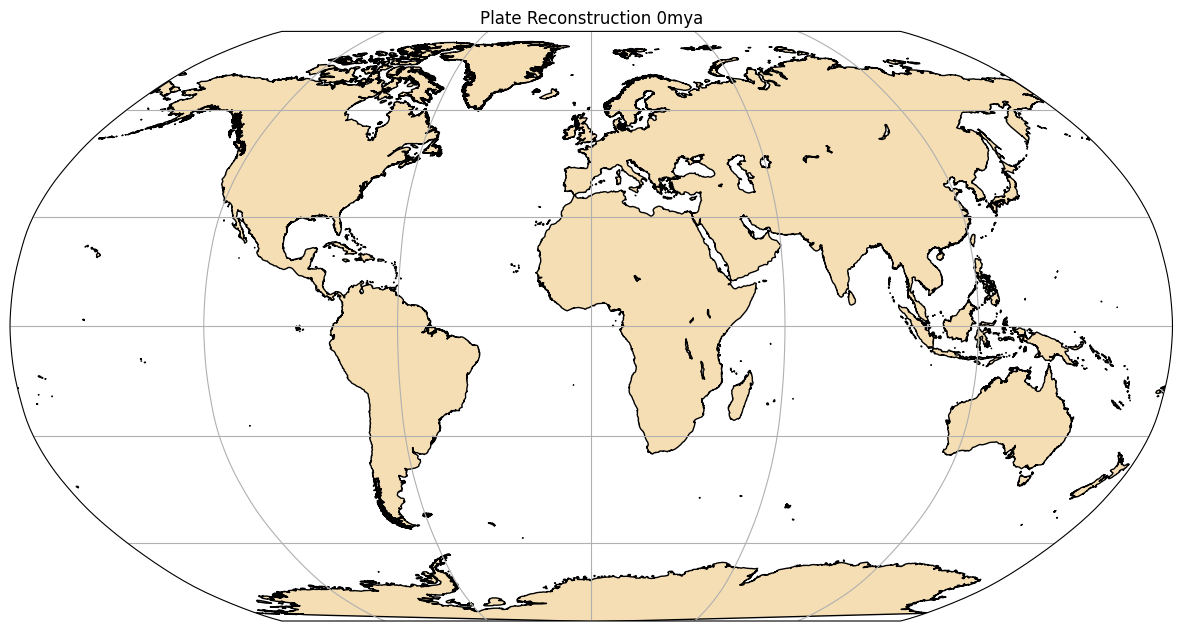

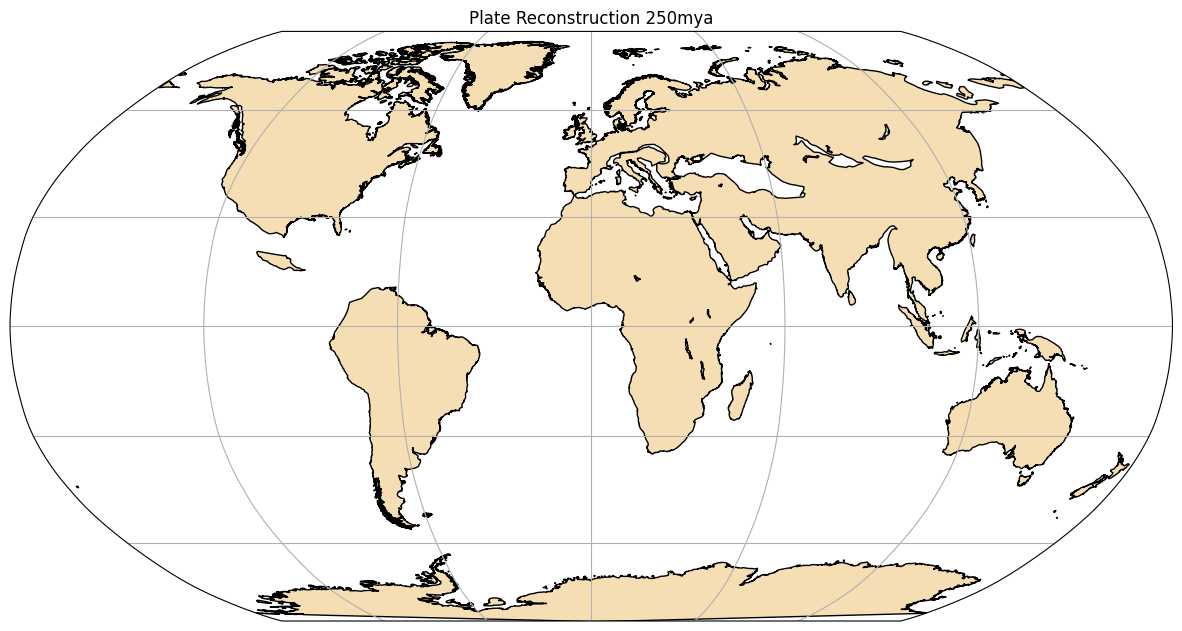

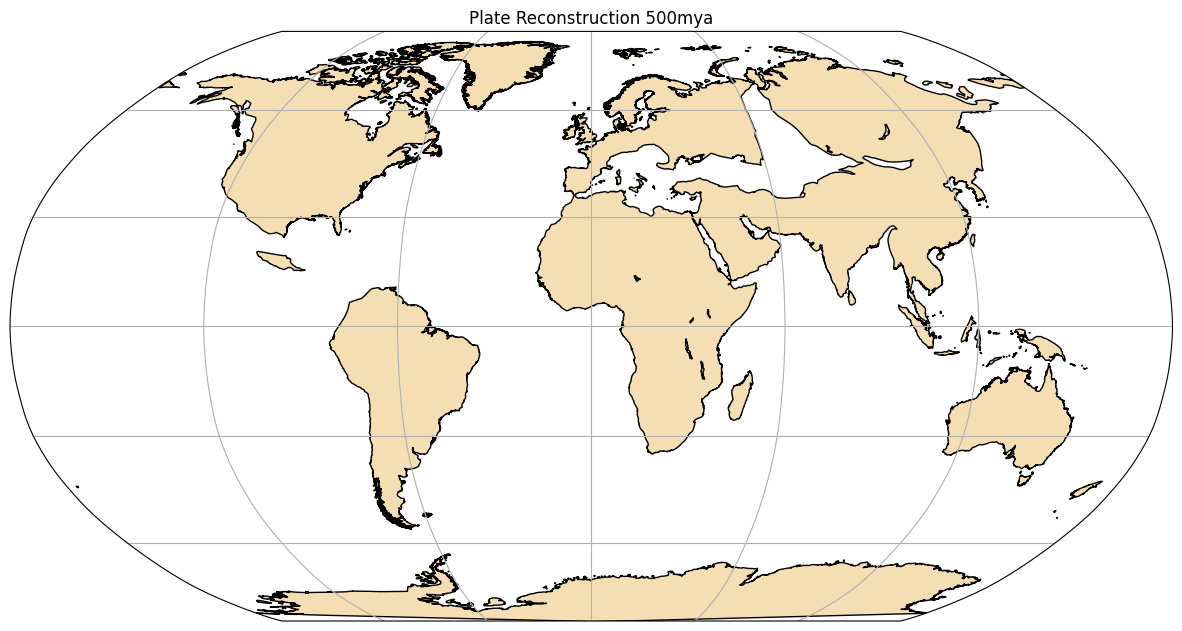

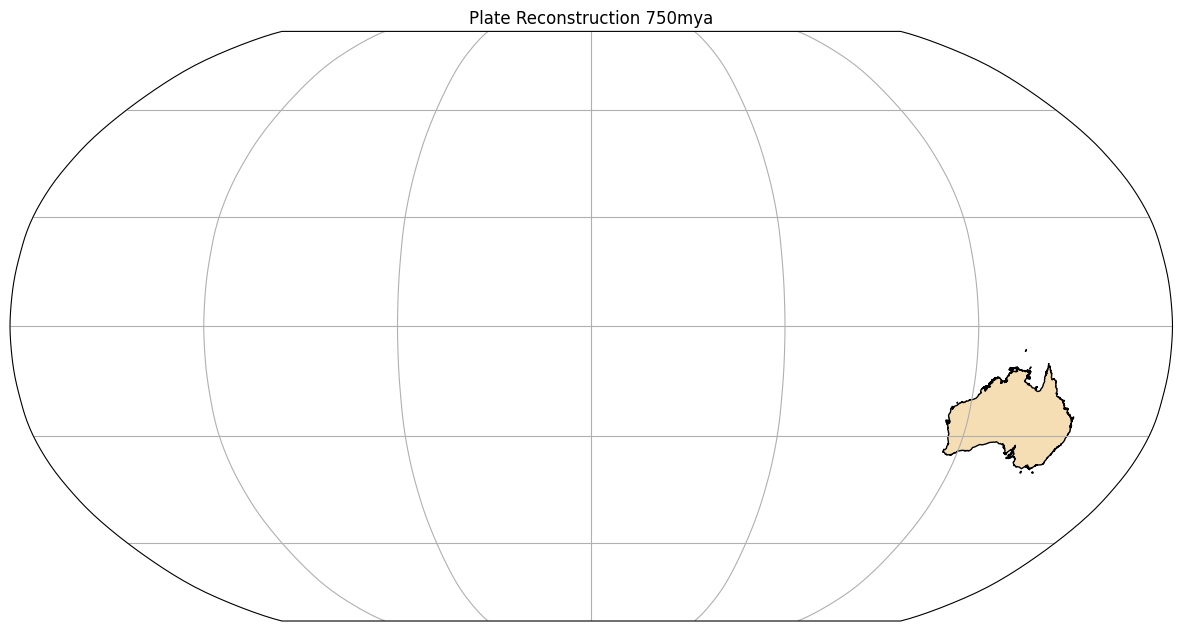

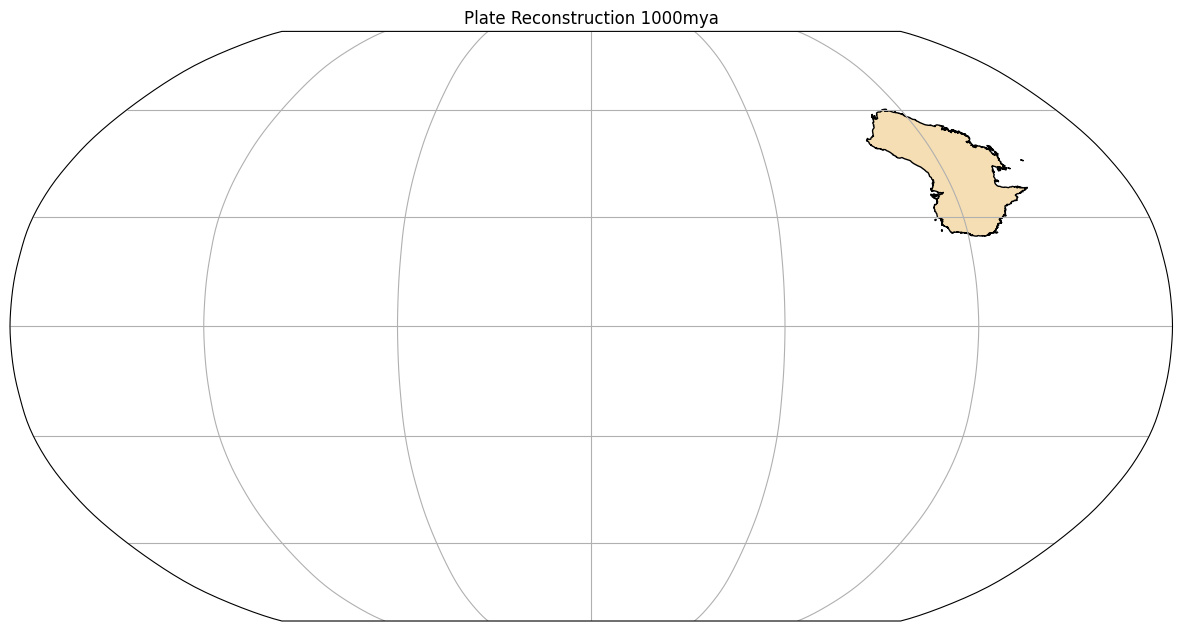

In [ ]:
for i in range(0,1001,250):
    # plotPyGplates(i)
    # print(i)
    rotatedPolygons = getReconstructedPolygons(i)

    splitPolys = fixAntimeridianCrossingPolygon(rotatedPolygons)

    unionMine = union_all([make_valid(i) for i in splitPolys])

    create_plate_map([unionMine], f'Plate Reconstruction {i}mya')

    plt.show()

In [ ]:
# for i in range(0, 410+1, 100):
#     pygplates.reconstruct('coastlines.gpml', 'rotation.rot', '/content/tmp.shp', i, 0)

#     fig = plt.figure(figsize=(14, 10))
#     ax_map = fig.add_subplot(111, projection=ccrs.Robinson())

#     shp_coast = shpreader.Reader('/content/tmp.shp')
#     ft_coast = cfeature.ShapelyFeature(shp_coast.geometries(), crs=ccrs.PlateCarree())

#     ax_map.add_feature(ft_coast, facecolor='wheat', edgecolor='black')

#     ax_map.set_title(f'PyGPlates Reconstruction {i}mya', fontsize=16)
#     plt.show()


In [ ]:
from google.colab import _message

# Get notebook JSON data
nb = _message.blocking_request('get_ipynb')['ipynb']

# Extract and print code from all cells
for i, cell in enumerate(nb['cells']):
    if cell['cell_type'] == 'code':
        print(f"### CELL {i} ###")
        print(''.join(cell['source']))
        print("\n--- CELL SEPARATOR ---\n")

### CELL 0 ###
!pip install geopandas
!pip install contextily
!pip install cartopy
!pip install networkx[default]
!pip install pygplates

--- CELL SEPARATOR ---

### CELL 1 ###
import gzip
import shutil
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from cartopy import *
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature
from shapely import *
import json
import pandas as pd
import numpy as np
import networkx as nx
from collections import *
import pygplates
from shapely.ops import split, unary_union
from shapely.geometry import LineString

--- CELL SEPARATOR ---

### CELL 2 ###
rotationDf = pd.read_csv('rotation.rot',
                 delim_whitespace=True,
                 names=['moving_plate_id',
                       'age_ma',
                       'euler_pole_lat',
                       'euler_pole_lon',
                       'rotation_angle',
                       'fixed_plate_id'],
                 com